#	Exercise 1: Compute autocorrelation

In [222]:
import numpy as np
import random
import matplotlib.pyplot as plt

**Step 1**: Generate the Chain: Reuse your Metropolis-Hastings code from the previous assignment to generate a chain of 
 samples.

In [223]:
# states
S = [0, 1, 2, 3, 4]

# discrete probability distribution
P = [.1, .2, .4, .2, .1]

# steps
# N = 1_000_000
N = 100_000

In [224]:
def get_distribution_stochastic(S, P, N):
    # create a dictionary to count the occurrences of each state
    occurrences = {state: 0 for state in S}
    # create a list to store the order of state transitions
    transitions = []

    # set initial state
    current = random.choice(S)

    # set step size
    step_size = 1

    # perform N steps of the simulation
    for _ in range(N):
        # update the occurrences of the current state
        occurrences[current] += 1
        # add the current state to the transitions list
        transitions.append(current)

        # generate a proposed state
        proposed = current + random.choice([-step_size, step_size])

        # calculate acceptance probability
        if proposed in S:
            acceptance = min(1.0, P[proposed] / P[current])
        else:
            acceptance = 0.0

        # accept or reject the proposed state (if rejected -> stay in the current state)
        if random.uniform(0, 1) < acceptance:
            current = proposed

    return occurrences, transitions

**Step 2**: Compute Errors:

*	Calculate the **standard deviation** $\sigma_{y}$ and the **naive error** $ \dfrac{\sigma_{y}}{\sqrt{N}} $.

*	Calculate the **autocovariance**
$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$
*	Calculate the **integrated autocorelation time** 
$$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$
and the **corrected error**

$$ \sigma_{\overline{y}} = \dfrac{1}{\sqrt{N}} \sigma_{y} \times \sqrt{2\tau_{int}}$$
<!-- 
where $$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$

$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$ -->

In [225]:
# get the distribution of states and the transitions from the simulation
occurences, transitions = get_distribution_stochastic(S, P, N)

# dict to save autocorrelations for each state to visualize
autocorrelations = {}

for state in S:
    y = np.array([1 if t == state else 0 for t in transitions])
    y_mean = np.mean(y)

    # 1 - calculate standard deviation and naive error
    std_dev = np.std(y)
    naive_err = std_dev / np.sqrt(N)

    print(f"State {state}:\n\tStandard Deviation: {std_dev:.6f}\n\tNaive Error: {naive_err:.6f}")

    # 2 - calculate autocovariance of the state
    auto_cov = np.zeros(N)
    auto_cov[0] = np.var(y)
    t_limit = N

    for t in range(1, N):
        y_front = y[:-t]
        y_back = y[t:]
        mean_prod = np.mean((y_front - y_mean) * (y_back - y_mean))

        auto_cov_t = (1 - (t / N)) * mean_prod

        # check if autocovariance is negative, if so, we can stop calculation
        if auto_cov_t < 0:
            t_limit = t
            break

        auto_cov[t] = auto_cov_t

    # 3 - calculate integrated autocorrelation time
    τ_int = 0.5 + np.sum(auto_cov[1:N] / auto_cov[0])

    # 4 - corrected error
    corr_err = (1 / np.sqrt(N)) * std_dev * np.sqrt(2 * τ_int)

    # save autocorrelations for visualization
    autocorrelations[state] = auto_cov[:t_limit] / auto_cov[0]

    print(f"\tIntegrated Autocorrelation Time: {τ_int:.6f}\n\tCorrected Error: {corr_err:.6f}")


State 0:
	Standard Deviation: 0.297693
	Naive Error: 0.000941
	Integrated Autocorrelation Time: 2.044364
	Corrected Error: 0.001904
State 1:
	Standard Deviation: 0.398014
	Naive Error: 0.001259
	Integrated Autocorrelation Time: 1.078040
	Corrected Error: 0.001848
State 2:
	Standard Deviation: 0.489158
	Naive Error: 0.001547
	Integrated Autocorrelation Time: 0.979213
	Corrected Error: 0.002165
State 3:
	Standard Deviation: 0.402092
	Naive Error: 0.001272
	Integrated Autocorrelation Time: 1.045407
	Corrected Error: 0.001839
State 4:
	Standard Deviation: 0.306682
	Naive Error: 0.000970
	Integrated Autocorrelation Time: 1.943170
	Corrected Error: 0.001912


**Step 3** Visualization: Plot the normalized autocorrelation function $\rho(t)$ against lag t
$$\rho(t) = \dfrac{C_y(t)}{C_y(0)}$$

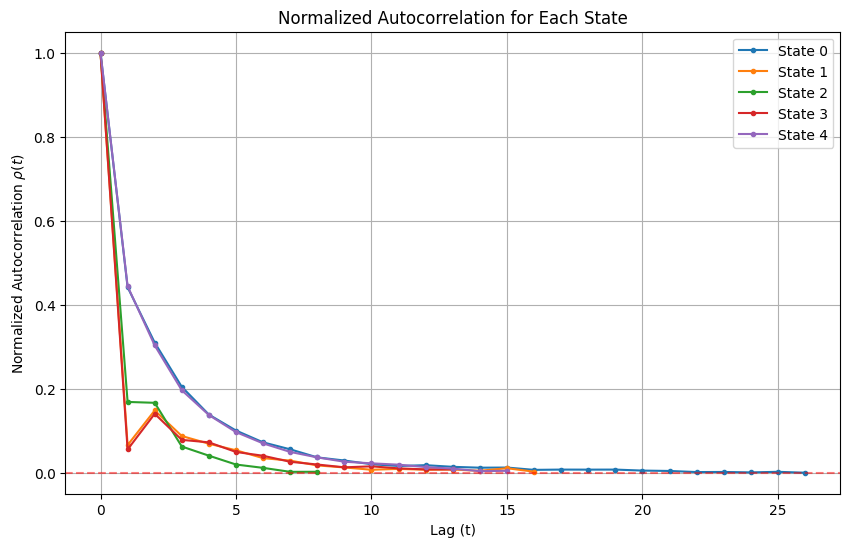

In [226]:
plt.figure(figsize=(10, 6))

for state, rho in autocorrelations.items():
    lags = np.arange(len(rho))
    plt.plot(lags, rho, marker='o', markersize=3, label=f'State {state}')

plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Lag (t)')
plt.ylabel(r'Normalized Autocorrelation $\rho(t)$')
plt.title('Normalized Autocorrelation for Each State')
plt.legend()
plt.grid()

plt.show()

**Questions**:
1.	What does it mean if $\rho(t)$ stays high for a long time (large t)?
    - It means that our simulation is strongly correlated and the simulation gets stuck in a single state for many iterations.
2.	If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
    - Effective Sample Size is formulated as: $N_{eff} = \dfrac{N}{2\tau_{int}}$, so the number of independent points is $\dfrac{100000}{2*50}$ that equals to 1000.
3.	How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?
    - Algorith spends most of it's time in an area of high probability so when it does large step it most likely would land in a part of lesser probability. That would affect the acceptance for the step and would effect in high reject count.